# Référence : ChatGPT helps

In [1]:

import pandas as pd
import numpy as np
import ast
from collections import Counter
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_curve

warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss, roc_auc_score

# 1. Exploration des données

## 1.0 Data viewing

In [2]:
train = pd.read_csv("Train.csv")
test  = pd.read_csv("Test.csv")
prior = pd.read_csv("Prior.csv")

TARGETS = [
    ('adopted_within_07_days',  '07'),
    ('adopted_within_90_days',  '90'),
    ('adopted_within_120_days', '120'),
]

print(f"Train: {train.shape}, Test: {test.shape}, Prior: {prior.shape}")
for t, l in TARGETS:
    print(f"  {l}j: {train[t].sum()} positifs ({train[t].mean():.2%})")


Train: (13536, 17), Test: (5621, 14), Prior: (44882, 17)
  07j: 153 positifs (1.13%)
  90j: 214 positifs (1.58%)
  120j: 302 positifs (2.23%)


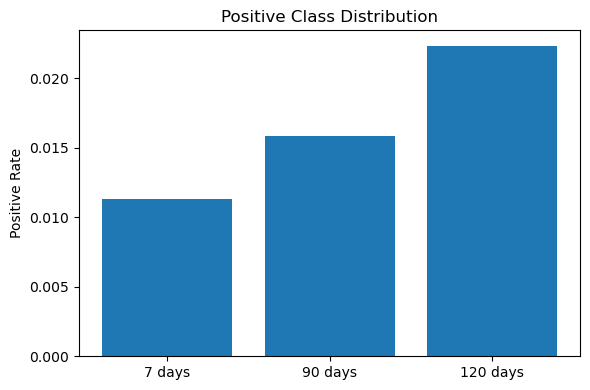

In [3]:
labels = ['7 days','90 days','120 days']
values = [
    train['adopted_within_07_days'].mean(),
    train['adopted_within_90_days'].mean(),
    train['adopted_within_120_days'].mean()
]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title("Positive Class Distribution")
plt.ylabel("Positive Rate")
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

## 1.1 Topic parsing + Historical adoption rate

In [4]:
def parse_topics(x):
    """Extrait la liste aplatie des sujets de formation."""
    try:
        val = ast.literal_eval(str(x))
        flat = []
        for item in val:
            if isinstance(item, list): flat.extend(item)
            else: flat.append(item)
        return flat
    except:
        return []

prior['topics_parsed'] = prior['topics_list'].apply(parse_topics)

# Calcul des taux d'adoption par topic, sur le PRIOR uniquement
topic_rate_maps = {}
for target_col, label in TARGETS:
    a = prior[prior[target_col] == 1]
    n = prior[prior[target_col] == 0]
    at = Counter([t for lst in a['topics_parsed'] for t in lst])
    nt = Counter([t for lst in n['topics_parsed'] for t in lst])
    all_t = set(list(at.keys()) + list(nt.keys()))
    rate_map = {}
    for t in all_t:
        total = at.get(t,0) + nt.get(t,0)
        if total >= 5:
            rate_map[t] = at.get(t,0)/total
    topic_rate_maps[label] = rate_map
print("Topic rate maps créés")

Topic rate maps créés


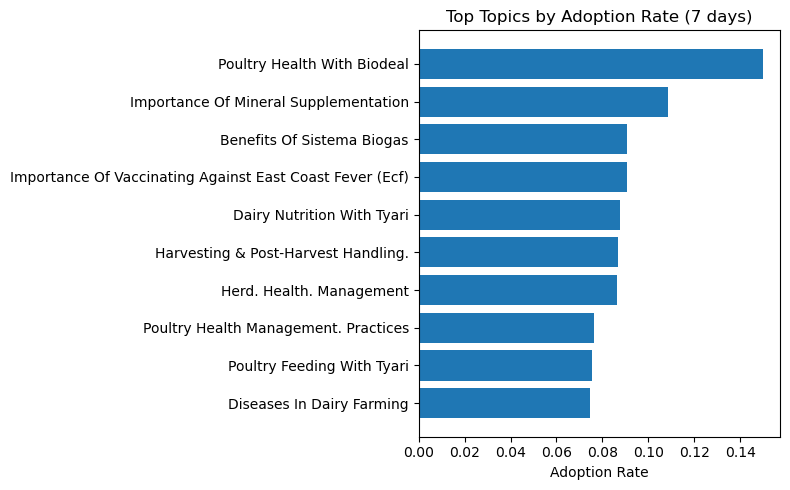

In [5]:
topic_rates = topic_rate_maps['07']
top_topics = sorted(topic_rates.items(), key=lambda x: x[1], reverse=True)[:10]

names = [x[0] for x in top_topics]
rates = [x[1] for x in top_topics]

plt.figure(figsize=(8,5))
plt.barh(names[::-1], rates[::-1])
plt.title("Top Topics by Adoption Rate (7 days)")
plt.xlabel("Adoption Rate")
plt.tight_layout()
plt.savefig("top_topics_rate.png")
plt.show()

# 2. Feature Engineering

In [6]:
def make_features(df, ref_df, topic_rate_maps):
    df = df.copy()
    df['topics_parsed'] = df['topics_list'].apply(parse_topics)
    df['training_day']  = pd.to_datetime(df['training_day'], errors='coerce')

    # Topics features
    df['n_topics']        = df['topics_parsed'].apply(len)
    df['n_unique_topics'] = df['topics_parsed'].apply(lambda x: len(set(x)))
    for label, rate_map in topic_rate_maps.items():
        def get_topic_quality(topics):
            rates = [rate_map.get(t,0) for t in topics]
            if not rates: return 0.0,0.0,0.0
            return float(max(rates)), float(np.mean(rates)), float(np.sum(rates))
        feats = df['topics_parsed'].apply(get_topic_quality)
        df[f'topic_max_{label}']  = feats.apply(lambda x:x[0])
        df[f'topic_mean_{label}'] = feats.apply(lambda x:x[1])
        df[f'topic_sum_{label}']  = feats.apply(lambda x:x[2])

    # Temporal features
    df['day_of_week']  = df['training_day'].dt.dayofweek
    df['month']        = df['training_day'].dt.month
    df['day_of_month'] = df['training_day'].dt.day
    df['quarter']      = df['training_day'].dt.quarter
    df['is_weekend']   = (df['day_of_week']>=5).astype(int)

    # Target encoding from prior
    entities = [
        ('farmer_name', 'farmer'), ('trainer', 'trainer'),
        ('group_name', 'group'), ('county', 'county'),
        ('ward', 'ward'), ('subcounty', 'subcounty'),
        ('registration', 'reg'), ('age', 'age'), ('gender','gender')
    ]
    for grp_col, prefix in entities:
        stats = ref_df.groupby(grp_col).agg(
            **{f'{prefix}_cnt': (grp_col,'count'),
               f'{prefix}_r07': ('adopted_within_07_days','mean'),
               f'{prefix}_r90': ('adopted_within_90_days','mean'),
               f'{prefix}_r120':('adopted_within_120_days','mean')}
        ).reset_index()
        df = df.merge(stats, on=grp_col, how='left')

    # Interaction features
    interactions = [
        ('trainer','county'),
        ('trainer','age'),
        ('county','registration'),
        ('ward','trainer'),
    ]
    for c1,c2 in interactions:
        key = f"{c1}_{c2}"
        ref_c = ref_df.copy()
        ref_c[key] = ref_c[c1].astype(str)+'_'+ref_c[c2].astype(str)
        df[key] = df[c1].astype(str)+'_'+df[c2].astype(str)
        st = ref_c.groupby(key).agg(
            **{f"{key}_r07":('adopted_within_07_days','mean'),
               f"{key}_cnt": (key,'count')}
        ).reset_index()
        df = df.merge(st, on=key, how='left')

    # Ratios
    df['farmer_vs_group']   = df['farmer_r07'] / (df['group_r07'] + 1e-5)
    df['farmer_vs_county']  = df['farmer_r07'] / (df['county_r07'] + 1e-5)
    df['trainer_vs_county'] = df['trainer_r07']/ (df['county_r07'] + 1e-5)

    # Label encoding
    cat_cols = ['gender','registration','age','county','subcounty','ward','trainer','group_name']
    for c in cat_cols:
        le = LabelEncoder()
        all_vals = list(set(list(ref_df[c].astype(str).unique()) + list(df[c].astype(str).unique())))
        le.fit(all_vals)
        df[c+'_le'] = le.transform(df[c].astype(str))

    # Drop raw list columns
    df = df.drop(columns=['topics_list','topics_parsed','training_day'])
    return df

train_fe = make_features(train, prior, topic_rate_maps)
test_fe  = make_features(test, prior, topic_rate_maps)
print(f"Feature engineering done — {train_fe.shape[1]} colonnes")

Feature engineering done — 90 colonnes


In [7]:
FCOLS = [c for c in train_fe.columns if (
    c.endswith('_le') or
    c.startswith('topic') or
    c in ['n_topics','n_unique_topics','day_of_week','month','day_of_month','quarter','is_weekend',
          'farmer_vs_group','farmer_vs_county','trainer_vs_county']
)]
print(f"Nombre de features sélectionnées: {len(FCOLS)}")


Nombre de features sélectionnées: 27


# 3. Entraînement

In [8]:
X_train = train_fe[FCOLS].values
X_test  = test_fe[FCOLS].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_store  = {}
test_store = {}

for target_col,label in TARGETS:
    y = train_fe[target_col].values
    pos = (y==1).sum(); neg = (y==0).sum()

    oof_hgb  = np.zeros(len(y))
    oof_et   = np.zeros(len(y))
    test_hgb = np.zeros(len(X_test))
    test_et  = np.zeros(len(X_test))

    for fold,(tr_idx,val_idx) in enumerate(skf.split(X_train,y)):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        # HistGradientBoosting
        m1 = HistGradientBoostingClassifier(
            max_iter=800, learning_rate=0.05, max_depth=7,
            min_samples_leaf=10, l2_regularization=0.1,
            random_state=42,
            class_weight={0:1, 1:neg/pos}
        )
        m1.fit(X_tr,y_tr)
        oof_hgb[val_idx] += m1.predict_proba(X_val)[:,1]
        test_hgb += m1.predict_proba(X_test)[:,1]/5

        # ExtraTrees calibré
        et_base = ExtraTreesClassifier(
            n_estimators=500, min_samples_leaf=5,
            class_weight='balanced', random_state=42, n_jobs=-1
        )
        m2 = CalibratedClassifierCV(et_base, cv=3, method='isotonic')
        m2.fit(X_tr,y_tr)
        oof_et[val_idx] += m2.predict_proba(X_val)[:,1]
        test_et += m2.predict_proba(X_test)[:,1]/5

        print(f"  {label}j fold {fold+1}/5 done")

    # Blend
    oof_blend = 0.5*oof_hgb + 0.5*oof_et
    test_blend = 0.5*test_hgb + 0.5*test_et

    oof_store[label]  = (y,oof_blend)
    test_store[label] = test_blend

    ll  = log_loss(y,oof_blend)
    auc = roc_auc_score(y,oof_blend)
    print(f"\n>>> Target {label}j: LogLoss={ll:.4f}, AUC={auc:.4f}\n")

  07j fold 1/5 done
  07j fold 2/5 done
  07j fold 3/5 done
  07j fold 4/5 done
  07j fold 5/5 done

>>> Target 07j: LogLoss=0.0789, AUC=0.9535

  90j fold 1/5 done
  90j fold 2/5 done
  90j fold 3/5 done
  90j fold 4/5 done
  90j fold 5/5 done

>>> Target 90j: LogLoss=0.0893, AUC=0.9422

  120j fold 1/5 done
  120j fold 2/5 done
  120j fold 3/5 done
  120j fold 4/5 done
  120j fold 5/5 done

>>> Target 120j: LogLoss=0.1150, AUC=0.9377



# 4. Création du fichier de soumission

In [9]:
try:
    ss = pd.read_csv("SampleSubmission.csv")
except FileNotFoundError:
    ss = pd.DataFrame({'ID': test['ID']})

for col,label in zip(['Target_07_LogLoss','Target_07_AUC',
                      'Target_90_LogLoss','Target_90_AUC',
                      'Target_120_LogLoss','Target_120_AUC'],
                     ['07','07','90','90','120','120']):
    ss[col] = test_store[label]

ss.to_csv("Submission_Ensemble.csv", index=False)
print("Submission saved: Submission_Ensemble.csv")


Submission saved: Submission_Ensemble.csv


# 6. Résumé des performances

In [10]:
print("="*50)
print("RÉSUMÉ — Validation croisée 5-fold")
print("="*50)
for target_col,label in TARGETS:
    y,oof = oof_store[label]
    ll  = log_loss(y,oof)
    auc = roc_auc_score(y,oof)
    print(f"Target {label}j : LogLoss={ll:.4f} | AUC={auc:.4f}")
print("="*50)

RÉSUMÉ — Validation croisée 5-fold
Target 07j : LogLoss=0.0789 | AUC=0.9535
Target 90j : LogLoss=0.0893 | AUC=0.9422
Target 120j : LogLoss=0.1150 | AUC=0.9377


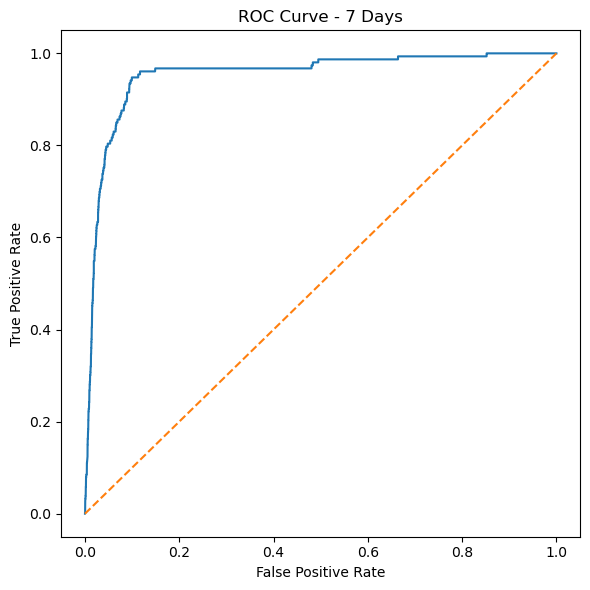

In [11]:

y_true, oof_pred = oof_store['07']
fpr, tpr, _ = roc_curve(y_true, oof_pred)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - 7 Days")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.savefig("roc_07.png")
plt.show()

In [12]:
# # =========================
# # LIBRARIES
# # =========================
# import pandas as pd
# import numpy as np
# import ast
# from collections import Counter
# import warnings
# warnings.filterwarnings("ignore")

# from sklearn.preprocessing import LabelEncoder
# from sklearn.model_selection import StratifiedKFold
# from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier
# from sklearn.calibration import CalibratedClassifierCV
# from sklearn.metrics import log_loss, roc_auc_score

# print("Libraries loaded ✅")

# # =========================
# # LOAD DATA
# # =========================
# train = pd.read_csv("Train.csv")
# test  = pd.read_csv("Test.csv")
# prior = pd.read_csv("Prior.csv")

# TARGETS = [
#     ('adopted_within_07_days',  '07'),
#     ('adopted_within_90_days',  '90'),
#     ('adopted_within_120_days', '120'),
# ]

# print(f"Train: {train.shape}, Test: {test.shape}, Prior: {prior.shape}")
# for t, l in TARGETS:
#     print(f"  {l}j: {train[t].sum()} positifs ({train[t].mean():.2%})")

# # =========================
# # TOPIC PARSING + HISTORICAL ADOPTION RATE
# # =========================
# def parse_topics(x):
#     """Extrait la liste aplatie des sujets de formation."""
#     try:
#         val = ast.literal_eval(str(x))
#         flat = []
#         for item in val:
#             if isinstance(item, list): flat.extend(item)
#             else: flat.append(item)
#         return flat
#     except:
#         return []

# prior['topics_parsed'] = prior['topics_list'].apply(parse_topics)

# # Calcul des taux d'adoption par topic, sur le PRIOR uniquement
# topic_rate_maps = {}
# for target_col, label in TARGETS:
#     a = prior[prior[target_col] == 1]
#     n = prior[prior[target_col] == 0]
#     at = Counter([t for lst in a['topics_parsed'] for t in lst])
#     nt = Counter([t for lst in n['topics_parsed'] for t in lst])
#     all_t = set(list(at.keys()) + list(nt.keys()))
#     rate_map = {}
#     for t in all_t:
#         total = at.get(t,0) + nt.get(t,0)
#         if total >= 5:
#             rate_map[t] = at.get(t,0)/total
#     topic_rate_maps[label] = rate_map
# print("Topic rate maps créés ✅")

# # =========================
# # FEATURE ENGINEERING
# # =========================
# def make_features(df, ref_df, topic_rate_maps):
#     df = df.copy()
#     df['topics_parsed'] = df['topics_list'].apply(parse_topics)
#     df['training_day']  = pd.to_datetime(df['training_day'], errors='coerce')

#     # ── Topics features
#     df['n_topics']        = df['topics_parsed'].apply(len)
#     df['n_unique_topics'] = df['topics_parsed'].apply(lambda x: len(set(x)))
#     for label, rate_map in topic_rate_maps.items():
#         def get_topic_quality(topics):
#             rates = [rate_map.get(t,0) for t in topics]
#             if not rates: return 0.0,0.0,0.0
#             return float(max(rates)), float(np.mean(rates)), float(np.sum(rates))
#         feats = df['topics_parsed'].apply(get_topic_quality)
#         df[f'topic_max_{label}']  = feats.apply(lambda x:x[0])
#         df[f'topic_mean_{label}'] = feats.apply(lambda x:x[1])
#         df[f'topic_sum_{label}']  = feats.apply(lambda x:x[2])

#     # ── Temporal features
#     df['day_of_week']  = df['training_day'].dt.dayofweek
#     df['month']        = df['training_day'].dt.month
#     df['day_of_month'] = df['training_day'].dt.day
#     df['quarter']      = df['training_day'].dt.quarter
#     df['is_weekend']   = (df['day_of_week']>=5).astype(int)

#     # ── Target encoding from prior
#     entities = [
#         ('farmer_name', 'farmer'), ('trainer', 'trainer'),
#         ('group_name', 'group'), ('county', 'county'),
#         ('ward', 'ward'), ('subcounty', 'subcounty'),
#         ('registration', 'reg'), ('age', 'age'), ('gender','gender')
#     ]
#     for grp_col, prefix in entities:
#         stats = ref_df.groupby(grp_col).agg(
#             **{f'{prefix}_cnt': (grp_col,'count'),
#                f'{prefix}_r07': ('adopted_within_07_days','mean'),
#                f'{prefix}_r90': ('adopted_within_90_days','mean'),
#                f'{prefix}_r120':('adopted_within_120_days','mean')}
#         ).reset_index()
#         df = df.merge(stats, on=grp_col, how='left')

#     # ── Interaction features
#     interactions = [
#         ('trainer','county'),
#         ('trainer','age'),
#         ('county','registration'),
#         ('ward','trainer'),
#     ]
#     for c1,c2 in interactions:
#         key = f"{c1}_{c2}"
#         ref_c = ref_df.copy()
#         ref_c[key] = ref_c[c1].astype(str)+'_'+ref_c[c2].astype(str)
#         df[key] = df[c1].astype(str)+'_'+df[c2].astype(str)
#         st = ref_c.groupby(key).agg(
#             **{f"{key}_r07":('adopted_within_07_days','mean'),
#                f"{key}_cnt": (key,'count')}
#         ).reset_index()
#         df = df.merge(st, on=key, how='left')

#     # ── Ratios
#     df['farmer_vs_group']   = df['farmer_r07'] / (df['group_r07'] + 1e-5)
#     df['farmer_vs_county']  = df['farmer_r07'] / (df['county_r07'] + 1e-5)
#     df['trainer_vs_county'] = df['trainer_r07']/ (df['county_r07'] + 1e-5)

#     # ── Label encoding
#     cat_cols = ['gender','registration','age','county','subcounty','ward','trainer','group_name']
#     for c in cat_cols:
#         le = LabelEncoder()
#         all_vals = list(set(list(ref_df[c].astype(str).unique()) + list(df[c].astype(str).unique())))
#         le.fit(all_vals)
#         df[c+'_le'] = le.transform(df[c].astype(str))

#     # ── Drop raw list columns
#     df = df.drop(columns=['topics_list','topics_parsed','training_day'])
#     return df

# train_fe = make_features(train, prior, topic_rate_maps)
# test_fe  = make_features(test, prior, topic_rate_maps)
# print(f"Feature engineering done — {train_fe.shape[1]} colonnes ✅")

# # =========================
# # SELECT FEATURES
# # =========================
# FCOLS = [c for c in train_fe.columns if (
#     c.endswith('_le') or
#     c.startswith('topic') or
#     c in ['n_topics','n_unique_topics','day_of_week','month','day_of_month','quarter','is_weekend',
#           'farmer_vs_group','farmer_vs_county','trainer_vs_county']
# )]
# print(f"Nombre de features sélectionnées: {len(FCOLS)}")

# # =========================
# # TRAIN MODELS
# # =========================
# X_train = train_fe[FCOLS].values
# X_test  = test_fe[FCOLS].values

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# oof_store  = {}
# test_store = {}

# for target_col,label in TARGETS:
#     y = train_fe[target_col].values
#     pos = (y==1).sum(); neg = (y==0).sum()

#     oof_hgb  = np.zeros(len(y))
#     oof_et   = np.zeros(len(y))
#     test_hgb = np.zeros(len(X_test))
#     test_et  = np.zeros(len(X_test))

#     for fold,(tr_idx,val_idx) in enumerate(skf.split(X_train,y)):
#         X_tr, X_val = X_train[tr_idx], X_train[val_idx]
#         y_tr, y_val = y[tr_idx], y[val_idx]

#         # HistGradientBoosting
#         m1 = HistGradientBoostingClassifier(
#             max_iter=800, learning_rate=0.05, max_depth=7,
#             min_samples_leaf=10, l2_regularization=0.1,
#             random_state=42,
#             class_weight={0:1, 1:neg/pos}
#         )
#         m1.fit(X_tr,y_tr)
#         oof_hgb[val_idx] += m1.predict_proba(X_val)[:,1]
#         test_hgb += m1.predict_proba(X_test)[:,1]/5

#         # ExtraTrees calibré
#         et_base = ExtraTreesClassifier(
#             n_estimators=500, min_samples_leaf=5,
#             class_weight='balanced', random_state=42, n_jobs=-1
#         )
#         m2 = CalibratedClassifierCV(et_base, cv=3, method='isotonic')
#         m2.fit(X_tr,y_tr)
#         oof_et[val_idx] += m2.predict_proba(X_val)[:,1]
#         test_et += m2.predict_proba(X_test)[:,1]/5

#         print(f"  {label}j fold {fold+1}/5 done")

#     # Blend
#     oof_blend = 0.5*oof_hgb + 0.5*oof_et
#     test_blend = 0.5*test_hgb + 0.5*test_et

#     oof_store[label]  = (y,oof_blend)
#     test_store[label] = test_blend

#     ll  = log_loss(y,oof_blend)
#     auc = roc_auc_score(y,oof_blend)
#     print(f"\n>>> Target {label}j: LogLoss={ll:.4f}, AUC={auc:.4f}\n")

# # =========================
# # SUBMISSION
# # =========================
# try:
#     ss = pd.read_csv("SampleSubmission.csv")
# except FileNotFoundError:
#     ss = pd.DataFrame({'ID': test['ID']})

# for col,label in zip(['Target_07_LogLoss','Target_07_AUC',
#                       'Target_90_LogLoss','Target_90_AUC',
#                       'Target_120_LogLoss','Target_120_AUC'],
#                      ['07','07','90','90','120','120']):
#     ss[col] = test_store[label]

# ss.to_csv("Submission_Ensemble.csv", index=False)
# print("Submission saved: Submission_Ensemble.csv ✅")

# # =========================
# # VALIDATION REPORT
# # =========================
# print("="*50)
# print("RÉSUMÉ — Validation croisée 5-fold")
# print("="*50)
# for target_col,label in TARGETS:
#     y,oof = oof_store[label]
#     ll  = log_loss(y,oof)
#     auc = roc_auc_score(y,oof)
#     print(f"Target {label}j : LogLoss={ll:.4f} | AUC={auc:.4f}")
# print("="*50)